# RLS (Recursive Least Squares)
We first have the necesary 3D spring analitical model formulation and a sphere volume path tracking with respective plots

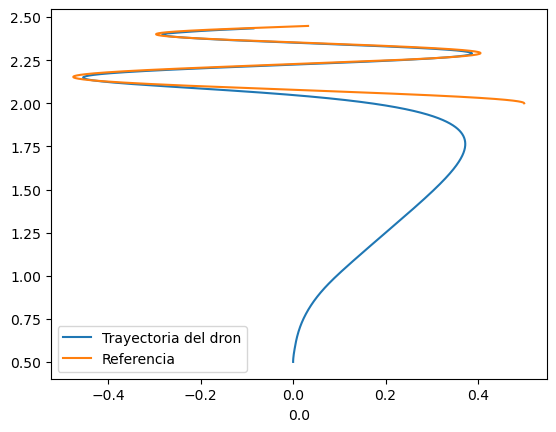

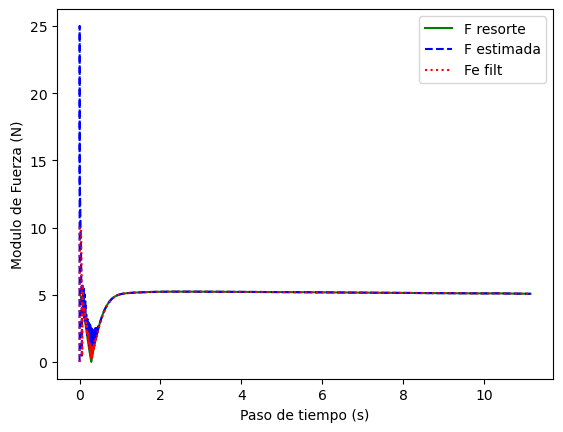

Fuerza estimada (filtrada) - media: 5.020126336600298 N


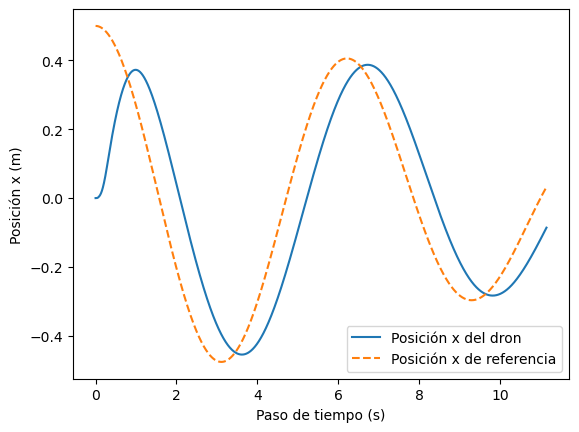

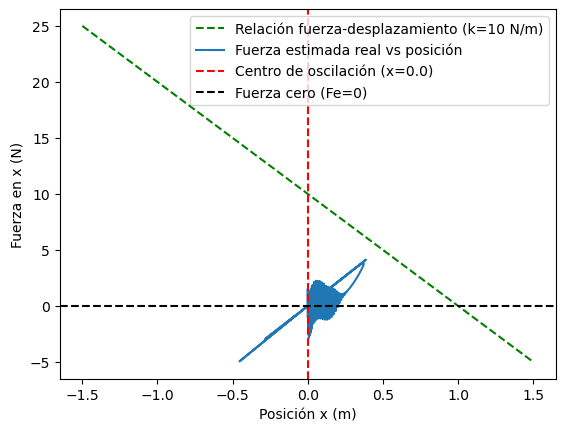

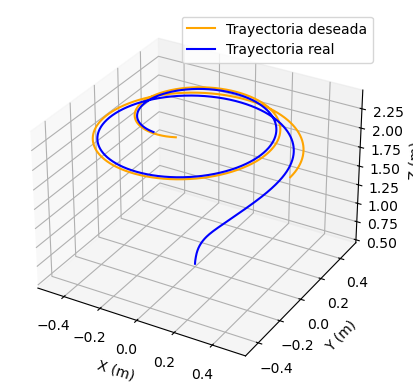

In [ ]:
import numpy as np
import mujoco
from mujoco import viewer
import time
import matplotlib.pyplot as plt
from low_level_controller.mellinguer import MellinguerController
from low_level_controller.indi import INDIController
from helper import ForceArrow, PointMarker, quat_to_rotmat
from plot import plot_force_vs_time, plot_trajectory, plot_traj_and_ref

from acceleration_estimator import AccelerationEstimator
from force_observer.force_observer import ForceObserver
from force_observer.force_filter import MovingAverageForgettingFactorFilter

from path_generator import PathGenerator



# --- XML con actuadores directos u1,u2,u3,u4 ---
XML_PATH = "system/drone_spring_sphere_obs_u1234.xml"  # <-- pon aquí tu nuevo XML

model = mujoco.MjModel.from_xml_path(XML_PATH)
data = mujoco.MjData(model)
dt = model.opt.timestep

arrowVF = ForceArrow(model, data, arrow_idx=1) # virtual force (mocap)
arrowEF = ForceArrow(model, data, arrow_idx=2) # estimated force (mocap)
markerT = PointMarker(model, data, marker_idx=1) # referencia deseada (mocap)

# Body del dron
drone_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "drone_3d")
if drone_id < 0:
    raise ValueError("No existe el body 'drone_3d' en el XML.")

# Masa total del dron
m = float(model.body_subtreemass[drone_id])

# Posición inicial para hover
mujoco.mj_forward(model, data)
p0 = data.xpos[drone_id].copy()

# Gains como lista: [Kp_pos, Kv_pos, KR_att, Komega_att]
gains = [
    np.array([5.0, 5.0, 10.0]),         # Kp posición (diag)
    np.array([3.0, 3.0, 6.0]),          # Kv velocidad (diag)
    np.array([8.0, 8.0, 2.0]),    # KR actitud (diag)
    np.array([0.2, 0.2, 0.1])         # Komega velocidad angular (diag)
]

controller = MellinguerController(mass=m, gravity=9.81, gains=gains)


# (Opcional) si quieres asignar por nombre para evitar depender del orden:
act_u1 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u1_thrust")
act_u2 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u2_tau_x")
act_u3 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u3_tau_y")
act_u4 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u4_tau_z")
if min(act_u1, act_u2, act_u3, act_u4) < 0:
    raise ValueError("No encontré actuadores u1_thrust/u2_tau_x/u3_tau_y/u4_tau_z. Revisa el XML.")


# Inicializar estimador de aceleración, observador de fuerza y filtro de fuerza
acceleration_estimator = AccelerationEstimator(dt)
force_observer = ForceObserver(drone_mass=m, gravity=9.81)
force_filter = MovingAverageForgettingFactorFilter(window_size=15, forgetting_factor=0.9)
path_generator = PathGenerator()

# guardar para debug/visualización
vector_r = []
vector_rT = []
vector_Fe = [] # para guardar la fuerza estimada real (sin filtrar)
vector_Fe_filt = [] # para guardar la fuerza estimada filtrada para comparar
vector_F_res = [] # para guardar la fuerza teorica real del resorte
# Fe inicial
Fe_filt = np.zeros(3)
Fe = np.zeros(3)

with viewer.launch_passive(model, data) as vis:
    t = 0.0

    while vis.is_running():
        # ---------------------------
        # (1) Leer estado en MuJoCo
        # ---------------------------
        r = data.xpos[drone_id].copy()
        q = data.xquat[drone_id].copy()
        R = quat_to_rotmat(q)

        # cvel = [wx, wy, wz, vx, vy, vz] (world-aligned)
        cvel = data.cvel[drone_id].copy()
        omega_world = cvel[0:3]
        vel_world = cvel[3:6]

        # aceleración estimada (derivada numérica)
        a = acceleration_estimator.estimate(vel_world, noise=False, noise_std=1.5)

        # Tu controlador típicamente usa omega en body
        omega_body = R.T @ omega_world

        # Calcular fuerza teórica del resorte en 3D
        # F = k*(x-x0)
        p0_res = np.array([0.0, 0.0, 2.0]) # centro de oscilación
        r_rel = r - p0_res # posición relativa al centro del spring
        k = 10.0 # constante del resorte
        r_eq = r_rel * (1.0 / np.linalg.norm(r_rel)) # vector de equilibrio con módulo 1.5
        F_res = -k * (r_rel - r_eq) # fuerza del resorte (vectorial)
        # vector_F_res.append(F_res)



        # rT, vT, aT = path_generator.fixed_point([1.0, 0.0, 2.0])
        # rT, vT, aT = path_generator.do_circle_xz(t, radius=0.5, center=np.array([1.0, 0.0, 1.5]), omega=1.0)
        # rT, vT, aT = path_generator.do_circle_xy(t, radius=0.5, center=np.array([1.0, 0.0, 1.5]), omega=1.0)
        # rT, vT, aT = path_generator.do_circle_xy(t, radius=1.0, center=np.array([0.0, 0.0, 2.0]), omega=1.0)
        # rT, vT, aT = path_generator.do_sine_x(t, center=np.array([1.0, 0.0, 2.0]), amplitude=0.4, frequency=1.0)
        # rT, vT, aT = path_generator.do_square_xz(t, center=np.array([1.0, 0.0, 2.0]), side_length=0.5, omega=1.0)
        # rT, vT, aT = path_generator.do_chirp_x(t, center=np.array([1.0, 0.0, 2.0]), amplitude=0.4, f0=0.5, f1=2.0, T=10.0) # chirp para probar respuesta a frecuencias variables
        # rT, vT, aT = path_generator.do_square_signal_x(t, center=np.array([1.0, 0.0, 2.0]), amplitude=0.4, frequency=0.2)
        rT, vT, aT = path_generator.do_spherical_spiral(t, center=np.array([0.0, 0.0, 2.0]), radius=0.5, omega=1.0, vertical_speed=0.1)
        # rT, vT, aT = path_generator.do_fill_spherical_spiral(t, center=np.array([0.0, 0.0, 2.0]), radius=2.0, omega=0.5*np.sqrt(2), vertical_speed=0.5*(2)**(1/4))

        yaw_d = 0.0
        
        # vT = 0 # vuelve el seguimiento más lento
        # aT = 0


        # guardar para debug/visualización
        vector_r.append(r)
        vector_rT.append(rT)
        vector_Fe.append(Fe) # guardar la fuerza estimada real (sin filtrar)
        vector_Fe_filt.append(Fe_filt) # guardar la fuerza estimada filtrada para comparar
        vector_F_res.append(F_res) # guardar la fuerza teorica real del resorte
        # ---------------------------
        # (3) Control Mellinger -> u = [u1,u2,u3,u4]
        # ---------------------------

        u, Fv, _ = controller.step(rT, vT, aT, r, vel_world, a, R, omega_body, yaw_d, f_ext=Fe_filt)

        Fe = force_observer.observe(u1_sclr=u[0], drone_acceleration=a, R=R)
        Fe_filt = force_filter.filter(Fe, limit=True, max_force=10.0) # limitar fuerza filtrada para evitar valores extremos que rompan la simulación

        # ---------------------------
        # (4) Aplicar controles directo a actuadores
        # ---------------------------
        data.ctrl[act_u1] = u[0]
        data.ctrl[act_u2] = u[1]
        data.ctrl[act_u3] = u[2]
        data.ctrl[act_u4] = u[3]

        # ---------------------------
        # (5) Actualizar flechas de fuerza / estimar fuerza real / actualizar marker de referencia
        # ---------------------------

        if arrowVF is not None:
            arrowVF.update_force_arrow_mocap(p0_world=r, F_world=Fv, scale=0.03, max_len=0.8, radius=0.01)

        if arrowEF is not None:
            arrowEF.update_force_arrow_mocap(p0_world=r, F_world=Fe, scale=0.03, max_len=0.8, radius=0.01)


        if markerT is not None:
            markerT.update_point(p_world=rT, radius=0.01)

        # ---------------------------
        # (6) Paso de simulación
        # ---------------------------
        start = time.time()

        mujoco.mj_step(model, data)
        vis.sync()
        t += dt

        alpha = 0  # factor de ajuste para sincronización (puedes experimentar con valores <1.0 si el código de control es muy pesado)

        # sincronizar en tiempo real
        elapsed = time.time() - start
        sleep_time = (dt - elapsed)*alpha
        if sleep_time > 0:
            time.sleep(sleep_time)


# # visualización de trayectoria (opcional)
vector_r = np.array(vector_r)
vector_rT = np.array(vector_rT)
vector_Fe = np.array(vector_Fe)
vector_Fe_filt = np.array(vector_Fe_filt)
vector_F_res = np.array(vector_F_res)
# plot_trajectory(vector_r[:,0], vector_r[:,2], p0[0])
plot_traj_and_ref(vector_r[:,0], vector_r[:,2], vector_rT[:,0], vector_rT[:,2], p0[0])


import numpy as np

axt = np.linspace(0, len(vector_Fe)*dt, len(vector_Fe))

plot_force_vs_time(
    axt,
    np.linalg.norm(vector_F_res, axis=1), 'F resorte', '-', 'green',
    np.linalg.norm(vector_Fe, axis=1), 'F estimada', '--', 'blue',
    np.linalg.norm(vector_Fe_filt, axis=1), 'Fe filt', ':', 'red'
    

)

print("Fuerza estimada (filtrada) - media:", np.mean(np.linalg.norm(vector_Fe_filt, axis=1)), "N")

# Visualizacion de posicion x con respecto al tiempo
plt.figure()
plt.plot(axt, vector_r[:,0], label='Posición x del dron')
plt.plot(axt, vector_rT[:,0], label='Posición x de referencia', linestyle='--')
plt.xlabel('Paso de tiempo (s)')
plt.ylabel('Posición x (m)')
plt.legend()
plt.show()


# visualización de fuerza estimada real vs posición
plt.figure()
# trazar recta y=-k*(x-1.0) para visualizar relación fuerza-desplazamiento (con k=10 N/m)
k = 10.0
x_vals = np.linspace(-1.5, 1.5, 100)
y_vals = -k * (x_vals - 1.0)
plt.plot(x_vals, y_vals, 'g--', label='Relación fuerza-desplazamiento (k=10 N/m)')
# trazar fuerza estimada real vs posición x
plt.plot(vector_r[:,0], vector_Fe[:,0], label='Fuerza estimada real vs posición')
# trazar linea vertical en x = 0.0 (centro de oscilación)
plt.axvline(x=0.0, color='r', linestyle='--', label='Centro de oscilación (x=0.0)')
# trazar linea horizontal en Fe=0
plt.axhline(y=0.0, color='k', linestyle='--', label='Fuerza cero (Fe=0)')

plt.xlabel('Posición x (m)')
plt.ylabel('Fuerza en x (N)')
plt.legend()
plt.show()



# plot 3d de la trayectoria deseada
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(vector_rT[:,0], vector_rT[:,1], vector_rT[:,2], label='Trayectoria deseada', color='orange')
ax.plot(vector_r[:,0], vector_r[:,1], vector_r[:,2], label='Trayectoria real', color='blue')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.legend()
plt.show()


# RLS Test

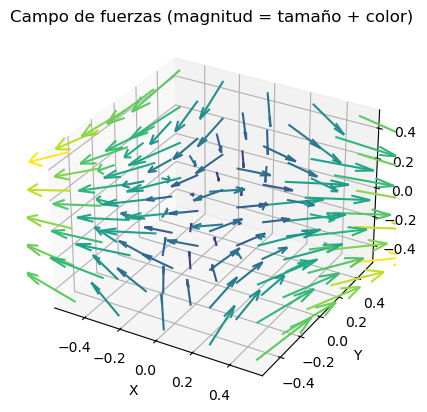

In [5]:
import numpy as np
from rls import RLS
from plot import plot_vector_field_3d

# Crear modelo
rls = RLS(n_features=4, n_outputs=3, lambda_=0.99, delta=1.0)

dt = 0.01

for t in range(1000):
    # Posición (ejemplo)
    x = np.sin(t * dt)
    y = np.cos(t * dt)
    z = 0.5 * np.sin(2 * t * dt)

    # Features
    phi = np.array([x, y, z, 1.0])

    # Campo real (desconocido)
    Fx = 2*x + 0.5*y
    Fy = -y + 0.3*z
    Fz = x - z

    F_real = np.array([Fx, Fy, Fz])

    # Update
    F_hat, error = rls.update(phi, F_real)

    # if t % 100 == 0:
    #     print(f"t={t}")
    #     print("F_hat:", F_hat)
    #     print("Error:", error)
    #     print()

plot_vector_field_3d(rls, grid_lim=0.5, n_points=5, scale=0.3)

# Spring Drone RLS (Recursive Least Squares)
Implement a force estimator for the object force as an external constant force.

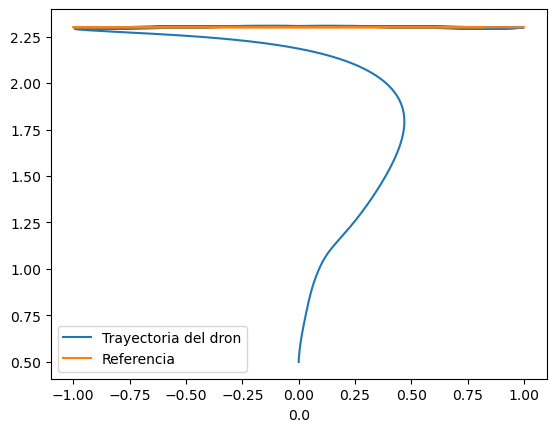

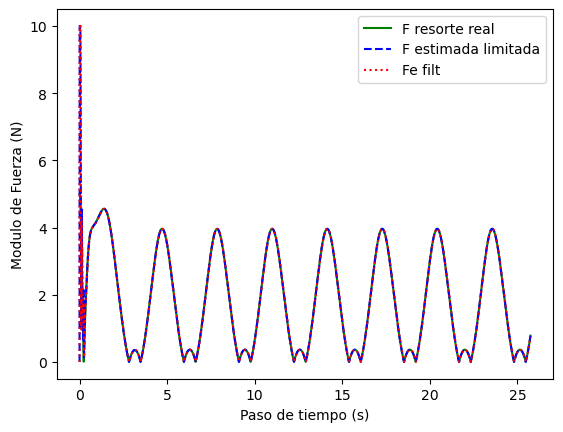

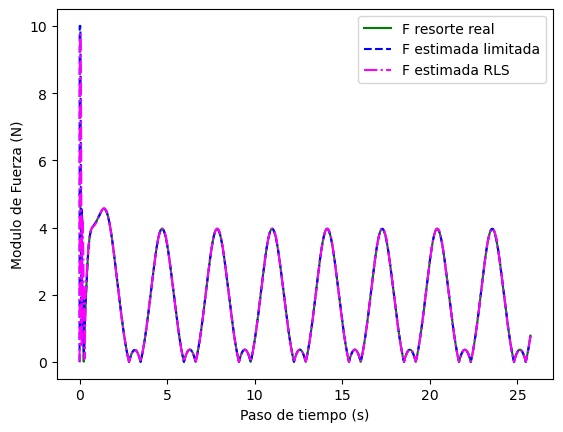

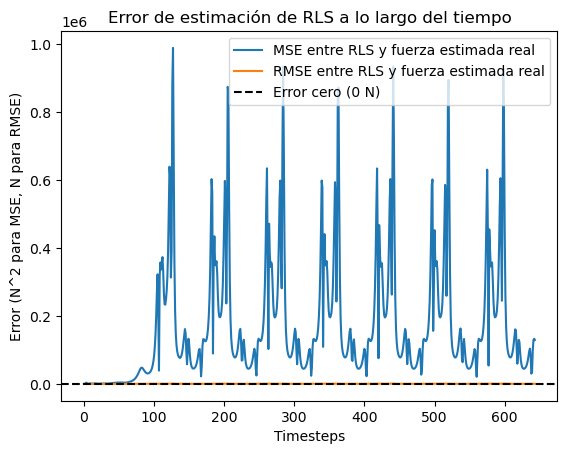

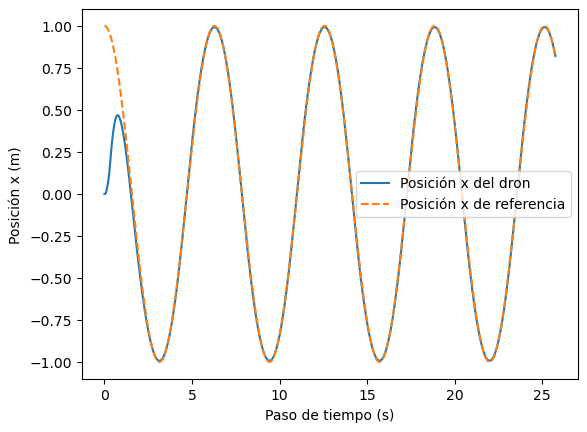

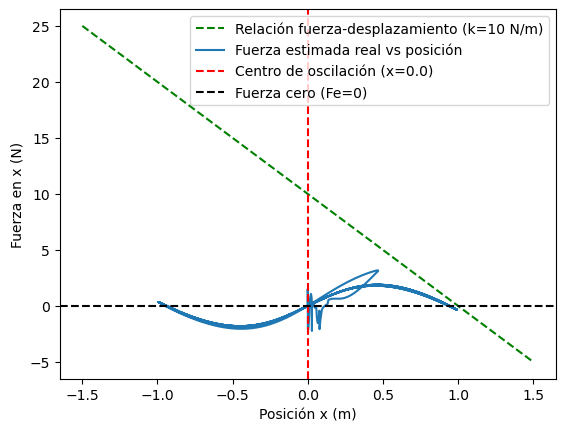

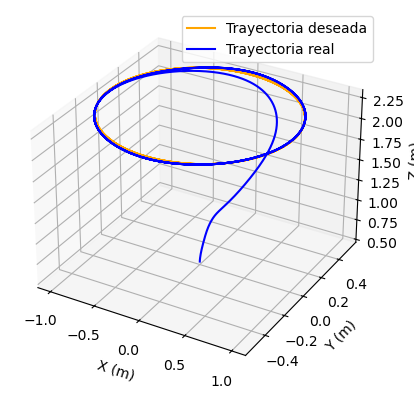

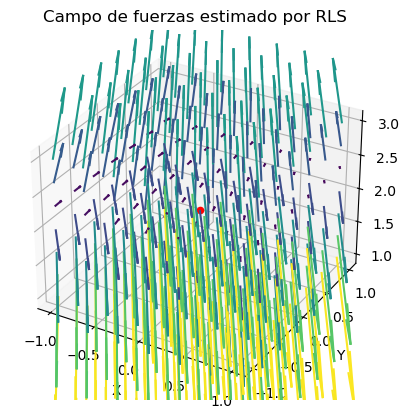

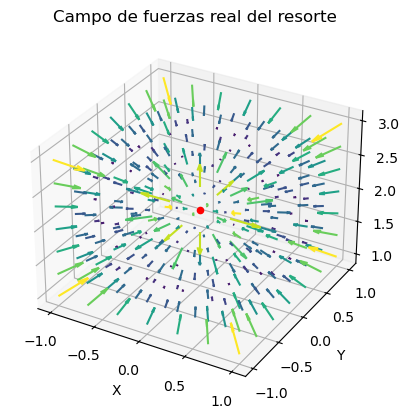

In [ ]:
import numpy as np
import mujoco
from mujoco import viewer
import time
import matplotlib.pyplot as plt
from low_level_controller.mellinguer import MellinguerController
from low_level_controller.indi import INDIController
from helper import ForceArrow, PointMarker, quat_to_rotmat
from plot import plot_force_vs_time, plot_trajectory, plot_traj_and_ref, plot_vector_field_3d, plot_true_vector_field_3d
from system.spring_models import linear_spring_force

from acceleration_estimator import AccelerationEstimator
from force_observer.force_observer import ForceObserver
from force_observer.force_filter import MovingAverageForgettingFactorFilter

from path_generator import PathGenerator

from rls import RLS

from metrics import evaluate_vector_field


# --- XML con actuadores directos u1,u2,u3,u4 ---
XML_PATH = "system/drone_spring_sphere_obs_u1234.xml"  # <-- pon aquí tu nuevo XML

model = mujoco.MjModel.from_xml_path(XML_PATH)
data = mujoco.MjData(model)
dt = model.opt.timestep

arrowVF = ForceArrow(model, data, arrow_idx=1) # virtual force (mocap)
arrowEF = ForceArrow(model, data, arrow_idx=2) # estimated force (mocap)
markerT = PointMarker(model, data, marker_idx=1) # referencia deseada (mocap)

# Body del dron
drone_id = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "drone_3d")
if drone_id < 0:
    raise ValueError("No existe el body 'drone_3d' en el XML.")

# Masa total del dron
m = float(model.body_subtreemass[drone_id])

# Posición inicial para hover
mujoco.mj_forward(model, data)
p0 = data.xpos[drone_id].copy()

# Gains como lista: [Kp_pos, Kv_pos, KR_att, Komega_att]
gains = [
    np.array([5.0, 5.0, 10.0]),         # Kp posición (diag)
    np.array([3.0, 3.0, 6.0]),          # Kv velocidad (diag)
    np.array([8.0, 8.0, 2.0]),    # KR actitud (diag)
    np.array([0.2, 0.2, 0.1])         # Komega velocidad angular (diag)
]

controller = MellinguerController(mass=m, gravity=9.81, gains=gains)


# (Opcional) si quieres asignar por nombre para evitar depender del orden:
act_u1 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u1_thrust")
act_u2 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u2_tau_x")
act_u3 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u3_tau_y")
act_u4 = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_ACTUATOR, "u4_tau_z")
if min(act_u1, act_u2, act_u3, act_u4) < 0:
    raise ValueError("No encontré actuadores u1_thrust/u2_tau_x/u3_tau_y/u4_tau_z. Revisa el XML.")


# Inicializar estimador de aceleración, observador de fuerza y filtro de fuerza
acceleration_estimator = AccelerationEstimator(dt)
force_observer = ForceObserver(drone_mass=m, gravity=9.81)
force_filter = MovingAverageForgettingFactorFilter(window_size=15, forgetting_factor=0.9)
path_generator = PathGenerator(dt=dt)

# Inicializar RLS para modelar la fuerza del resorte
ForceRLS = RLS(n_features=4, n_outputs=3, lambda_=0.99, delta=1.0) # 4 features (x,y,z,1), 3 outputs (Fx,Fy,Fz)

# guardar para debug/visualización
vector_r = []
vector_rT = []
vector_Fe = [] # para guardar la fuerza estimada real (sin filtrar)
vector_Fe_filt = [] # para guardar la fuerza estimada filtrada para comparar
vector_F_res = [] # para guardar la fuerza teorica real del resorte
vector_F_est_RLS = [] # para guardar la fuerza estimada por RLS
vector_Fe_lim = [] # para guardar la fuerza estimada filtrada limitada para comparar con RLS
vector_mse_rmse = [] # para guardar MSE y RMSE entre RLS y fuerza estimada real
# Fe inicial
Fe_filt = np.zeros(3)
Fe_lim = np.zeros(3)
Fe = np.zeros(3)
F_est_RLS = np.zeros(3)

with viewer.launch_passive(model, data) as vis:
    t = 0.0

    while vis.is_running():
        # ---------------------------
        # (1) Leer estado en MuJoCo
        # ---------------------------
        r = data.xpos[drone_id].copy()
        q = data.xquat[drone_id].copy()
        R = quat_to_rotmat(q)

        # cvel = [wx, wy, wz, vx, vy, vz] (world-aligned)
        cvel = data.cvel[drone_id].copy()
        omega_world = cvel[0:3]
        vel_world = cvel[3:6]

        # aceleración estimada (derivada numérica)
        a = acceleration_estimator.estimate(vel_world, noise=False, noise_std=1.5)

        # Tu controlador típicamente usa omega en body
        omega_body = R.T @ omega_world

        # Calcular fuerza teórica del resorte en 3D
        # F = k*(x-x0)
        p0_res = np.array([0.0, 0.0, 2.0]) # centro de oscilación
        k = 10.0 # constante del resorte
        F_res = linear_spring_force(r, p0_res, k)



        # rT, vT, aT = path_generator.fixed_point([1.0, 0.0, 2.0])
        # rT, vT, aT = path_generator.do_circle_xz(t, radius=0.5, center=np.array([1.0, 0.0, 1.5]), omega=1.0)
        # rT, vT, aT = path_generator.do_circle_xy(t, radius=0.5, center=np.array([1.0, 0.0, 1.5]), omega=1.0)
        rT, vT, aT = path_generator.do_elipse_xy(t, radius_x=1.0, radius_y=0.5, center=np.array([0.0, 0.0, 0.0*np.sin(0.1*t)+2.3]), omega=1.0)
        # rT, vT, aT = path_generator.do_circle_xy(t, radius=1.0, center=np.array([0.0, 0.0, 2.0]), omega=1.0)
        # rT, vT, aT = path_generator.do_sine_x(t, center=np.array([1.0, 0.0, 2.0]), amplitude=0.4, frequency=1.0)
        # rT, vT, aT = path_generator.do_sine_x(t, center=np.array([0.0, 0.0, 1.5]), amplitude=1.5, frequency=0.2)
        # rT, vT, aT = path_generator.do_square_xz(t, center=np.array([1.0, 0.0, 2.0]), side_length=0.5, omega=1.0)
        # rT, vT, aT = path_generator.do_chirp_x(t, center=np.array([1.0, 0.0, 2.0]), amplitude=0.4, f0=0.5, f1=2.0, T=10.0) # chirp para probar respuesta a frecuencias variables
        # rT, vT, aT = path_generator.do_square_signal_x(t, center=np.array([1.0, 0.0, 2.0]), amplitude=0.4, frequency=0.2)
        # rT, vT, aT = path_generator.do_spherical_spiral(t, center=np.array([0.0, 0.0, 2.0]), radius=0.5, omega=1.0, vertical_speed=0.1)
        # rT, vT, aT = path_generator.do_fill_spherical_spiral(t, center=np.array([0.0, 0.0, 2.0]), radius=1.5, omega=0.5*np.sqrt(2), vertical_speed=0.5*(2)**(1/4))
        # if t <= 20.0: # durante los primeros 20 segundos, hacer la trayectoria más compleja para que RLS tenga datos variados para aprender
        #     rT, vT, aT = path_generator.do_fill_spherical_spiral(t, center=np.array([0.0, 0.0, 2.0]), radius=1.5, omega=0.5*np.sqrt(2), vertical_speed=0.5*(2)**(1/4))




        yaw_d = 0.0
        
        # vT = 0 # vuelve el seguimiento más lento
        # aT = 0


        # guardar para debug/visualización
        vector_r.append(r)
        vector_rT.append(rT)
        vector_Fe.append(Fe) # guardar la fuerza estimada real (sin filtrar)
        vector_Fe_filt.append(Fe_filt) # guardar la fuerza estimada filtrada para comparar
        vector_Fe_lim.append(Fe_lim) # guardar la fuerza estimada filtrada limitada para comparar con RLS
        vector_F_res.append(F_res) # guardar la fuerza teorica real del resorte
        vector_F_est_RLS.append(F_est_RLS) # guardar la fuerza estimada por RLS




        # Update RLS con la fuerza estimada real (sin filtrar) y las features (x,y,z,1)
        phi = np.hstack((r, 1.0)) # features: posición + bias
        ForceRLS.update(phi, Fe_lim) # actualizar modelo con la fuerza estimada real
        # Puedes usar ForceRLS.predict(phi) para obtener la fuerza estimada por el modelo
        F_est_RLS = ForceRLS.predict(phi)


        # ---------------------------
        # (3) Control Mellinger -> u = [u1,u2,u3,u4]
        # ---------------------------

        u, Fv, _ = controller.step(rT, vT, aT, r, vel_world, a, R, omega_body, yaw_d, f_ext=F_est_RLS)

        Fe = force_observer.observe(u1_sclr=u[0], drone_acceleration=a, R=R)
        Fe_lim = force_filter.limiter(Fe, max_force=10.0) # limitar fuerza observada para evitar valores extremos que rompan la simulación
        Fe_filt = force_filter.filter(Fe_lim) # limitar fuerza filtrada para evitar valores extremos que rompan la simulación


        # ---------------------------
        # (4) Aplicar controles directo a actuadores
        # ---------------------------
        data.ctrl[act_u1] = u[0]
        data.ctrl[act_u2] = u[1]
        data.ctrl[act_u3] = u[2]
        data.ctrl[act_u4] = u[3]

        # ---------------------------
        # (5) Actualizar flechas de fuerza / estimar fuerza real / actualizar marker de referencia
        # ---------------------------

        if arrowVF is not None:
            arrowVF.update_force_arrow_mocap(p0_world=r, F_world=Fv, scale=0.03, max_len=0.8, radius=0.01)

        if arrowEF is not None:
            arrowEF.update_force_arrow_mocap(p0_world=r, F_world=Fe, scale=0.03, max_len=0.8, radius=0.01)


        if markerT is not None:
            markerT.update_point(p_world=rT, radius=0.01)


        # Metricas para evaluar modelo RLS
        if int(t / dt) % 40 == 0: # evaluar cada 10 pasos para no sobrecargar la simulación
            metrics = evaluate_vector_field(
                model=ForceRLS,
                true_force_fn=linear_spring_force,
                center=np.array([0.0, 0.0, 2.0]),
                grid_lim=1.5,
                n_points=10)

            mse_rmse = np.array([metrics['MSE'], metrics['RMSE']])
            vector_mse_rmse.append(mse_rmse)


        # ---------------------------
        # (6) Paso de simulación
        # ---------------------------
        start = time.time()

        mujoco.mj_step(model, data)
        vis.sync()
        t += dt

        alpha = 0  # factor de ajuste para sincronización (puedes experimentar con valores <1.0 si el código de control es muy pesado)

        # sincronizar en tiempo real
        elapsed = time.time() - start
        sleep_time = (dt - elapsed)*alpha
        if sleep_time > 0:
            time.sleep(sleep_time)


# # visualización de trayectoria (opcional)
vector_r = np.array(vector_r)
vector_rT = np.array(vector_rT)
vector_Fe = np.array(vector_Fe)
vector_Fe_filt = np.array(vector_Fe_filt)
vector_F_res = np.array(vector_F_res)
vector_F_est_RLS = np.array(vector_F_est_RLS)
# plot_trajectory(vector_r[:,0], vector_r[:,2], p0[0])
plot_traj_and_ref(vector_r[:,0], vector_r[:,2], vector_rT[:,0], vector_rT[:,2], p0[0])


import numpy as np

axt = np.linspace(0, len(vector_Fe)*dt, len(vector_Fe))

plot_force_vs_time(
    axt,
    np.linalg.norm(vector_F_res, axis=1), 'F resorte real', '-', 'green',
    np.linalg.norm(vector_Fe_lim, axis=1), 'F estimada limitada', '--', 'blue',
    np.linalg.norm(vector_Fe_filt, axis=1), 'Fe filt', ':', 'red'
)

plot_force_vs_time(
    axt,
    np.linalg.norm(vector_F_res, axis=1), 'F resorte real', '-', 'green',
    np.linalg.norm(vector_Fe_lim, axis=1), 'F estimada limitada', '--', 'blue',
    np.linalg.norm(vector_F_est_RLS, axis=1), 'F estimada RLS', '-.', 'magenta'
)


# print RMSE con respecto al tiempo
vector_mse_rmse = np.array(vector_mse_rmse)
plt.figure()
plt.plot(vector_mse_rmse[:,0], label='MSE entre RLS y fuerza estimada real')
plt.plot(vector_mse_rmse[:,1], label='RMSE entre RLS y fuerza estimada real')
plt.axhline(y=0.0, color='k', linestyle='--', label='Error cero (0 N)')
plt.xlabel('Timesteps')
plt.ylabel('Error (N^2 para MSE, N para RMSE)')
plt.title('Error de estimación de RLS a lo largo del tiempo')
plt.legend()
plt.show()



# Visualizacion de posicion x con respecto al tiempo
plt.figure()
plt.plot(axt, vector_r[:,0], label='Posición x del dron')
plt.plot(axt, vector_rT[:,0], label='Posición x de referencia', linestyle='--')
plt.xlabel('Paso de tiempo (s)')
plt.ylabel('Posición x (m)')
plt.legend()
plt.show()


# visualización de fuerza estimada real vs posición
plt.figure()
# trazar recta y=-k*(x-1.0) para visualizar relación fuerza-desplazamiento (con k=10 N/m)
k = 10.0
x_vals = np.linspace(-1.5, 1.5, 100)
y_vals = -k * (x_vals - 1.0)
plt.plot(x_vals, y_vals, 'g--', label='Relación fuerza-desplazamiento (k=10 N/m)')
# trazar fuerza estimada real vs posición x
plt.plot(vector_r[:,0], vector_Fe[:,0], label='Fuerza estimada real vs posición')
# trazar linea vertical en x = 0.0 (centro de oscilación)
plt.axvline(x=0.0, color='r', linestyle='--', label='Centro de oscilación (x=0.0)')
# trazar linea horizontal en Fe=0
plt.axhline(y=0.0, color='k', linestyle='--', label='Fuerza cero (Fe=0)')

plt.xlabel('Posición x (m)')
plt.ylabel('Fuerza en x (N)')
plt.legend()
plt.show()



# plot 3d de la trayectoria deseada
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(vector_rT[:,0], vector_rT[:,1], vector_rT[:,2], label='Trayectoria deseada', color='orange')
ax.plot(vector_r[:,0], vector_r[:,1], vector_r[:,2], label='Trayectoria real', color='blue')
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.legend()
plt.show()

# Visualización del campo vectorial estimado por RLS
plot_vector_field_3d(ForceRLS, grid_lim=1.0, n_points=7, scale=0.005, title="Campo de fuerzas estimado por RLS")

plot_true_vector_field_3d(grid_lim=1.0, center=np.array([0.0, 0.0, 2.0]), n_points=7, scale=0.05, title="Campo de fuerzas real del resorte")








# Plot de modulo del error entre fuerza estimada por RLS y fuerza real del resorte en el tiempo
error_RLS = np.linalg.norm(vector_F_est_RLS - vector_F_res, axis=1)
error_filt = np.linalg.norm(vector_Fe_filt - vector_F_res, axis=1)
plt.figure()
plt.plot(axt, error_RLS, label='Error entre F_est_RLS y F_res')
plt.plot(axt, error_filt, label='Error entre F_filt y F_res')
# agregar linea horizontal para visualizar error cero
plt.axhline(y=0.0, color='k', linestyle='--', label='Error cero (0 N)')
plt.xlabel('Paso de tiempo (s)')
plt.ylabel('Error (N)')
plt.title('Error de estimación de RLS a lo largo del tiempo')
plt.legend()
plt.show()

# Plot de modulo del error entre posición del dron y posición de referencia en el tiempo
error_pos = np.linalg.norm(vector_r - vector_rT, axis=1)
plt.figure()
plt.plot(axt, error_pos, label='Error de posición (||r - rT||)')
plt.axhline(y=0.0, color='k', linestyle='--', label='Error cero (0 N)')
plt.xlabel('Paso de tiempo (s)')
plt.ylabel('Error de posición (m)')
plt.title('Error de posición a lo largo del tiempo')
plt.legend()
plt.show()


metrics = evaluate_vector_field(
    model=ForceRLS,
    true_force_fn=linear_spring_force,
    center=np.array([0.0, 0.0, 2.0]),
    grid_lim=1.5,
    n_points=10
)

for k, v in metrics.items():
    print(f"{k}: {v:.6f}")

vec_metrics = np.array([metrics['MSE'], metrics['RMSE']])



In [31]:
print(vector_mse_rmse)

[[56.12250716  7.49149566]]
